## 1. Import Libraries and Load Data

# Customer Sales Analysis Dashboard

This notebook analyzes customer sales performance using order-level sales data. It calculates core KPIs, compares revenue by month, region, product category, and customer, then exports chart images to the `images/` folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

project_root = Path.cwd()
if project_root.name == "notebook":
    project_root = project_root.parent

data_path = project_root / "data" / "customer_sales_data.csv"
images_dir = project_root / "images"
images_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path, parse_dates=["order_date"])
df.head()

,order_id,order_date,customer_id,customer_name,region,state,product_category,product,sales_channel,quantity,unit_price,discount_rate
0,1001,2025-01-04,C001,Ava Johnson,South,TX,Electronics,Wireless Mouse,Online,3,24.99,0.05
1,1002,2025-01-08,C002,Liam Smith,West,CA,Furniture,Office Chair,Retail,1,189.99,0.10
2,1003,2025-01-12,C003,Mia Davis,Midwest,IL,Office Supplies,Notebook Pack,Online,8,12.50,0.00
3,1004,2025-01-19,C004,Noah Brown,Northeast,NY,Electronics,USB-C Hub,Online,2,49.99,0.07
4,1005,2025-01-23,C005,Emma Wilson,South,FL,Office Supplies,Desk Organizer,Retail,4,18.75,0.00


## 2. Data Quality Checks

In [2]:
# Missing values by column
missing_values = df.isnull().sum().to_frame(name="missing_count")

# Duplicate and invalid numeric records
quality_checks = pd.DataFrame(
    {
        "check": [
            "Duplicate records",
            "Negative quantities",
            "Negative prices",
        ],
        "count": [
            df.duplicated().sum(),
            (df["quantity"] < 0).sum(),
            (df["unit_price"] < 0).sum(),
        ],
    }
)

display(missing_values)
quality_checks

,missing_count
order_id,0
order_date,0
customer_id,0
customer_name,0
region,0
state,0
product_category,0
product,0
sales_channel,0
quantity,0


,check,count
0,Duplicate records,0
1,Negative quantities,0
2,Negative prices,0


## 3. Prepare Revenue Columns

In [3]:
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * df["discount_rate"]
df["net_sales"] = df["gross_sales"] - df["discount_amount"]
df["month"] = df["order_date"].dt.to_period("M").astype(str)

df[["order_id", "order_date", "customer_name", "product_category", "gross_sales", "discount_amount", "net_sales"]].head()

,order_id,order_date,customer_name,product_category,gross_sales,discount_amount,net_sales
0,1001,2025-01-04,Ava Johnson,Electronics,74.97,3.7485,71.2215
1,1002,2025-01-08,Liam Smith,Furniture,189.99,18.9990,170.9910
2,1003,2025-01-12,Mia Davis,Office Supplies,100.00,0.0000,100.0000
3,1004,2025-01-19,Noah Brown,Electronics,99.98,6.9986,92.9814
4,1005,2025-01-23,Emma Wilson,Office Supplies,75.00,0.0000,75.0000


## 4. Dashboard KPIs

In [4]:
kpis = pd.DataFrame(
    {
        "metric": [
            "Total Revenue",
            "Total Orders",
            "Average Order Value",
            "Unique Customers",
            "Total Units Sold",
        ],
        "value": [
            df["net_sales"].sum(),
            df["order_id"].nunique(),
            df["net_sales"].mean(),
            df["customer_id"].nunique(),
            df["quantity"].sum(),
        ],
    }
)

kpis

,metric,value
0,Total Revenue,5413.96120
1,Total Orders,40.00000
2,Average Order Value,135.34903
3,Unique Customers,20.00000
4,Total Units Sold,149.00000


## 5. Monthly Revenue Trend

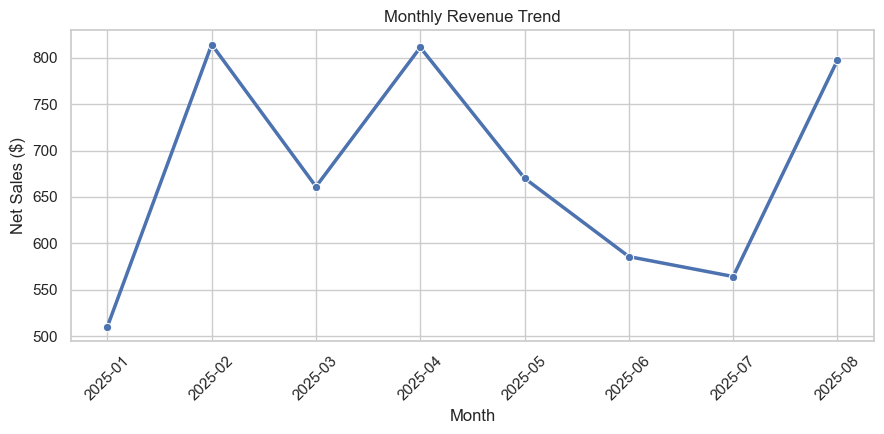

In [5]:
monthly_sales = df.groupby("month", as_index=False)["net_sales"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=monthly_sales, x="month", y="net_sales", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Net Sales ($)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.savefig(images_dir / "monthly_revenue.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Revenue by Region

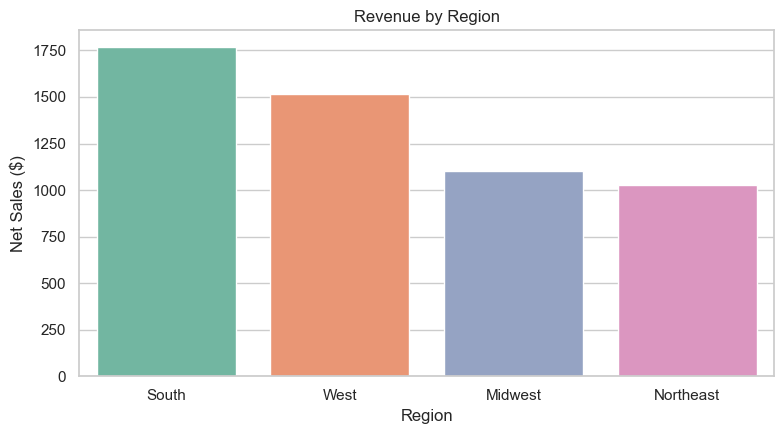

In [6]:
region_sales = df.groupby("region", as_index=False)["net_sales"].sum().sort_values("net_sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=region_sales, x="region", y="net_sales", hue="region", palette="Set2", legend=False, ax=ax)
ax.set_title("Revenue by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Net Sales ($)")
fig.tight_layout()
fig.savefig(images_dir / "revenue_by_region.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Product Category Performance

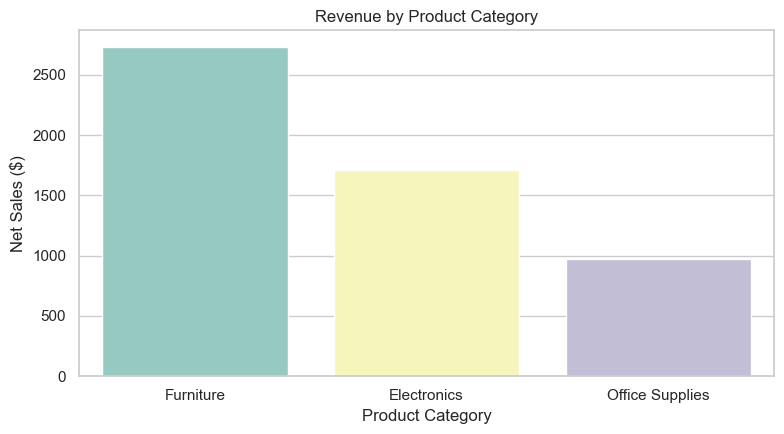

In [7]:
category_sales = df.groupby("product_category", as_index=False)["net_sales"].sum().sort_values("net_sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=category_sales, x="product_category", y="net_sales", hue="product_category", palette="Set3", legend=False, ax=ax)
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Net Sales ($)")
fig.tight_layout()
fig.savefig(images_dir / "revenue_by_product_category.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Top Customers

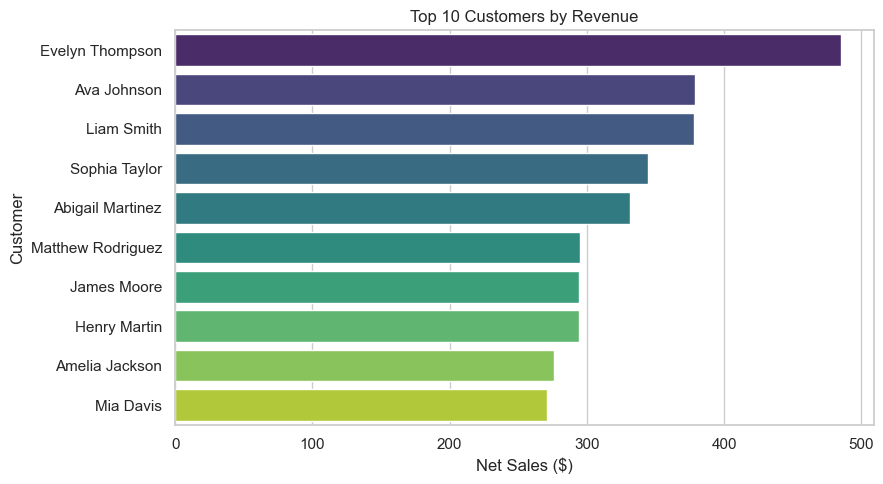

In [8]:
top_customers = (
    df.groupby(["customer_id", "customer_name"], as_index=False)["net_sales"]
    .sum()
    .sort_values("net_sales", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_customers, x="net_sales", y="customer_name", hue="customer_name", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Customer")
fig.tight_layout()
fig.savefig(images_dir / "top_customers_by_revenue.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Channel and Category Summary

In [9]:
channel_category_summary = pd.pivot_table(
    df,
    values="net_sales",
    index="sales_channel",
    columns="product_category",
    aggfunc="sum",
    fill_value=0,
)

channel_category_summary

product_category,Electronics,Furniture,Office Supplies
sales_channel,,,
Online,1706.7947,0.0000,900.891
Retail,0.0000,2731.2755,75.000


## Project Results

### Data Quality Validation

- Missing Values: 0
- Duplicate Records: 0
- Negative Quantities: 0
- Negative Prices: 0

### Key Metrics

- Total Revenue: $5,413.96
- Total Orders: 40
- Average Order Value: $135.35
- Unique Customers: 20
- Total Units Sold: 149

## Key Takeaways

- Compare monthly revenue to identify seasonality or demand changes.
- Use regional revenue to decide where sales or marketing support should be focused.
- Review top customers for retention, upsell, and relationship-building opportunities.
- Product category performance can guide inventory planning and promotions.

## Business Recommendations

1. Expand marketing in top-performing regions.
2. Focus inventory investment on highest revenue categories.
3. Develop retention programs for top customers.
4. Increase investment in strongest-performing sales channels.